In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
visa_df=pd.read_csv(r"C:\Users\Teja\Downloads\Visadataset - Visadataset.csv")

In [2]:
num=visa_df.select_dtypes(exclude='object').columns
cat=visa_df.select_dtypes(include='object').columns

**Why Scaling**

- Scaling preserve the numerical stability across the columns
- ex : Age : 24   salary : 500000    ex : 2
- Different columns having the different scale(limit)
- We want to keep all the columns under same limit
- If we dont keep under same scale some ML algo feels salary is the important column
    - Because of the highest value

**faster training**

- Some of ML algorithms like **KNN,KMEANS,SVM** are distance based algorithms
- if we lower the values the calculations are fast
- In every Model development will do math calculations
- In order to increase the fastness(optimization) scaling is very helpful

**Z score**

In [3]:
wage_data=visa_df['prevailing_wage']

In [ ]:
# step1- wage_mean=wage_data.mean()
# step2=wage_std
# step3= nr=wage_data-wage_mean
# step4=nr/wage_std

In [6]:
wage_mean=wage_data.mean()
wage_sd=wage_data.std()
nr=wage_data-wage_mean
z=nr/wage_sd
z

0       -1.398510
1        0.169832
2        0.919060
3        0.169991
4        1.428576
           ...   
25475    0.049923
25476    3.876083
25477    1.360253
25478    0.221504
25479   -0.067762
Name: prevailing_wage, Length: 25480, dtype: float64

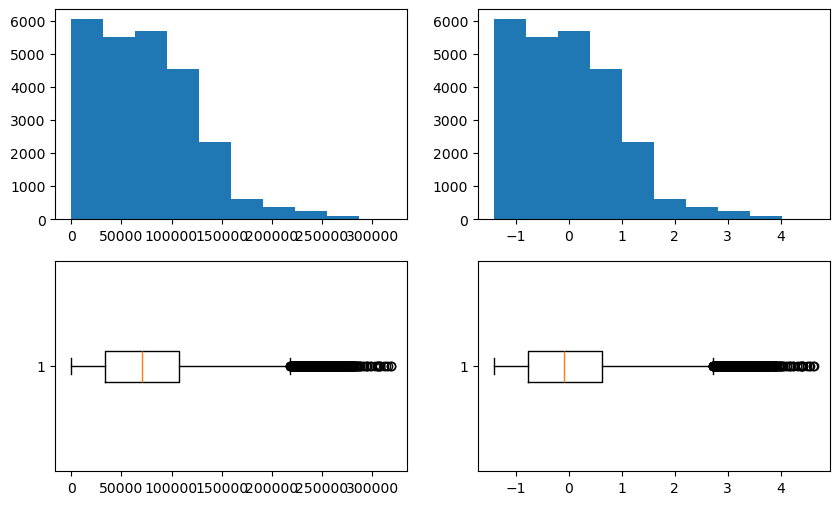

In [8]:
# old_data: wage_data
# z_data : wage_z
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(z,vert=False)
plt.show()

- sklearn
    -preprocessing
        - standard scalar
            - fit_transform

In [12]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
wage_data_ss=st.fit_transform(visa_df[['prevailing_wage']])

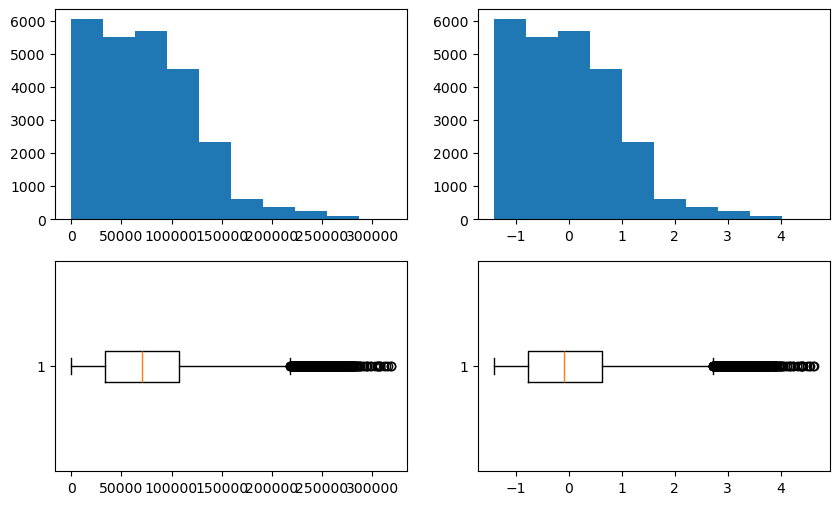

In [13]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_data_ss)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_data_ss,vert=False)
plt.show()

**normalization**

In [5]:
wage_min=wage_data.min()
wage_max=wage_data.max()
nr=wage_data-wage_min
dr=wage_max-wage_min
wage_norm=nr/dr

In [15]:
wage_norm

0        0.001849
1        0.261345
2        0.385312
3        0.261371
4        0.469616
           ...   
25475    0.241505
25476    0.874579
25477    0.458311
25478    0.269895
25479    0.222033
Name: prevailing_wage, Length: 25480, dtype: float64

In [ ]:
# standardscaler is called as z score
# minmax scalar si called a norm 0 to 1


In [8]:
from sklearn.preprocessing import MinMaxScaler
mns=MinMaxScaler()
mns.fit_transform([wage_data])

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 25480))